# White-Matter Hyperintensity (WMH) Segmentation

**Week 1 Deliverable**

BME 4408 — Medical Imaging Course Project

**Dataset:** MICCAI 2017 WMH Segmentation Challenge found at https://doi.org/10.34894/AECRSD

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage

plt.rcParams["figure.facecolor"] = "white"

DATA_ROOT = Path("../data/raw")
TRAIN_ROOT = DATA_ROOT / "training"
TEST_ROOT = DATA_ROOT / "test"

def load_canonical(path):
    """Load a NIfTI file and reorient it to RAS so 'slice along axis 2' reliably means axial,
    regardless of how a given scanner originally wrote its array."""
    return nib.as_closest_canonical(nib.load(path))

## 1. Sample Images

This dataset was collected at three hospitals, each on a different MRI scanner:
- Utrecht: 3T Philips Achieva
- Singapore: 3T Siemens TrioTim
- Amsterdam: 3T GE Signa HDxt

Here is one training subject from each site.
- T1
- FLAIR
- FLAIR overlaid with the WMH reference mask.

Even at a glance you can see contrast and slice-thickness differences between scanners.

That cross-scanner variability is a real theme we'll have to handle later.

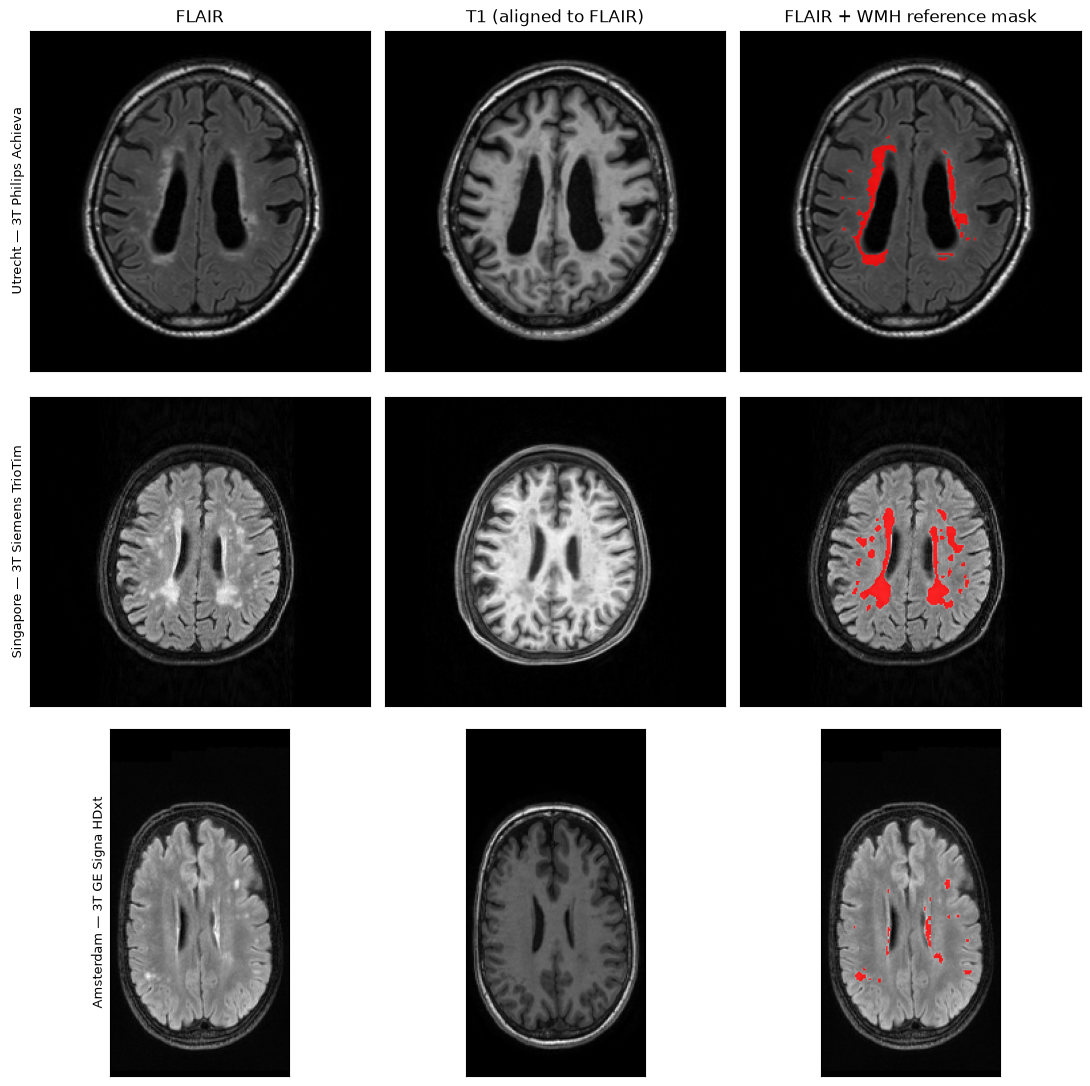

In [2]:
sample_sites = [
    ("Utrecht — 3T Philips Achieva", TRAIN_ROOT / "Utrecht" / "0"),
    ("Singapore — 3T Siemens TrioTim", TRAIN_ROOT / "Singapore" / "50"),
    ("Amsterdam — 3T GE Signa HDxt", TRAIN_ROOT / "Amsterdam" / "GE3T" / "100"),
]

fig, axes = plt.subplots(len(sample_sites), 3, figsize=(11, 11))

for row, (label, subj_dir) in enumerate(sample_sites):
    flair = load_canonical(subj_dir / "pre" / "FLAIR.nii.gz")
    t1 = load_canonical(subj_dir / "pre" / "T1.nii.gz")
    wmh = load_canonical(subj_dir / "wmh.nii.gz")

    flair_data = np.asarray(flair.dataobj)
    t1_data = np.asarray(t1.dataobj)
    wmh_data = np.asarray(wmh.dataobj)

    # Pick the slice with the most WMH voxels rather than the array's geometric midpoint:
    # Amsterdam's FLAIR is 3D-acquired with a much larger superior-inferior field of view
    # than Utrecht/Singapore's 2D acquisition, so shape[2]//2 there lands near the orbits,
    # not mid-cerebrum. Anchoring on WMH density keeps every row anatomically comparable.
    wmh_per_slice = np.sum(wmh_data == 1, axis=(0, 1))
    mid_z = int(np.argmax(wmh_per_slice))

    axes[row, 0].imshow(flair_data[:, :, mid_z].T, cmap="gray", origin="lower")
    axes[row, 0].set_ylabel(label, fontsize=9)
    axes[row, 0].set_title("FLAIR" if row == 0 else "")

    axes[row, 1].imshow(t1_data[:, :, mid_z].T, cmap="gray", origin="lower")
    axes[row, 1].set_title("T1 (aligned to FLAIR)" if row == 0 else "")

    axes[row, 2].imshow(flair_data[:, :, mid_z].T, cmap="gray", origin="lower")
    wmh_masked = np.ma.masked_where(wmh_data[:, :, mid_z].T != 1, wmh_data[:, :, mid_z].T)
    axes[row, 2].imshow(wmh_masked, cmap="autumn", alpha=0.85, origin="lower")
    axes[row, 2].set_title("FLAIR + WMH reference mask" if row == 0 else "")

    for col, ax in enumerate(axes[row]):
        ax.set_xticks([]); ax.set_yticks([])
        if col > 0:
            ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 2. Data distribution

Our problem is **segmentation**, not classification.

The subjects are distributed across:  

a) Sites/scanners  
b) How much WMH lesion burden each subject carries  
c) Voxel-level imbalance between WMH and background within a single scan  

**Patient demographics** Subjects were **70.1 ± 9.3 years old, 50% male** (Kuijf et al., 2019).

### a) Sites/Scanners

In [3]:
def count_subjects(root):
    """Counts subject folders per site, handling both flat sites (Utrecht, Singapore)
    and Amsterdam's extra scanner-name sublevel."""
    counts = {}
    for site_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        entries = [p for p in sorted(site_dir.iterdir()) if p.is_dir()]
        looks_like_subjects = any((p / "wmh.nii.gz").exists() or (p / "orig").exists() for p in entries)
        if looks_like_subjects:
            counts[site_dir.name] = len(entries)
        else:
            for scanner_dir in entries:
                sub_entries = [q for q in scanner_dir.iterdir() if q.is_dir()]
                counts[f"{site_dir.name} ({scanner_dir.name})"] = len(sub_entries)
    return counts

train_counts = count_subjects(TRAIN_ROOT)
test_counts = count_subjects(TEST_ROOT)

df_counts = pd.DataFrame({"train": pd.Series(train_counts), "test": pd.Series(test_counts)}).fillna(0).astype(int)
df_counts.loc["TOTAL"] = df_counts.sum()
df_counts

,train,test
Amsterdam (GE1T5),0,10
Amsterdam (GE3T),20,30
Amsterdam (Philips_VU .PETMR_01.),0,10
Singapore,20,30
Utrecht,20,30
TOTAL,60,110


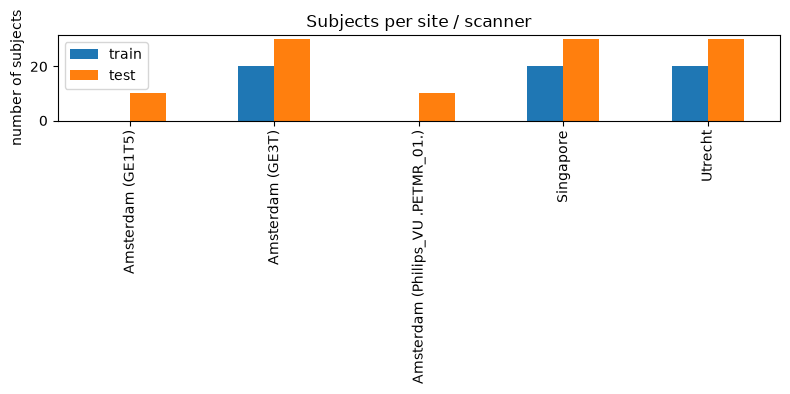

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
df_counts.drop("TOTAL").plot(kind="bar", ax=ax)
ax.set_ylabel("number of subjects")
ax.set_title("Subjects per site / scanner")
plt.tight_layout()
plt.show()

Two of the five test scanners never appear in training at all.

These are unseen scanners that the eventual segmentation model will be tested against.

Unlike a 2D chest X-ray dataset, each subject here isn't one image. It's a set of 3D brain **volumes**:
- an original of both T1 and FLAIR
- a bias-field-corrected version of both
- plus the WMH reference mask

In [5]:
example_subject = TRAIN_ROOT / "Utrecht" / "0"
example_files = sorted(p.relative_to(example_subject) for p in example_subject.rglob("*.nii.gz"))
print(f"NIfTI volumes for one typical subject ({example_subject.relative_to(DATA_ROOT)}):")
for f in example_files:
    print(" ", f)

total_train_nifti = sum(1 for _ in TRAIN_ROOT.rglob("*.nii.gz"))
total_test_nifti = sum(1 for _ in TEST_ROOT.rglob("*.nii.gz"))
print(f"\nTotal NIfTI volumes: {total_train_nifti} (training), {total_test_nifti} (test)")

n_extra_masks = sum(1 for _ in (TRAIN_ROOT / "Amsterdam" / "GE3T").rglob("*_mask.nii.gz")
                     if _.parent.name == "orig" and _.name != "3DT1_mask.nii.gz")

NIfTI volumes for one typical subject (training/Utrecht/0):
  orig/3DT1.nii.gz
  orig/3DT1_mask.nii.gz
  orig/FLAIR.nii.gz
  orig/T1.nii.gz
  pre/3DT1.nii.gz
  pre/FLAIR.nii.gz
  pre/T1.nii.gz
  wmh.nii.gz

Total NIfTI volumes: 520 (training), 980 (test)


### b) How much WMH lesion burden each subject carries

In [6]:
def lesion_volume_ml(wmh_path):
    img = load_canonical(wmh_path)
    data = np.asarray(img.dataobj)
    voxel_vol_mm3 = float(np.prod(img.header.get_zooms()[:3]))
    n_wmh_voxels = int(np.sum(data == 1))
    return n_wmh_voxels * voxel_vol_mm3 / 1000.0  # mm^3 -> mL

records = []
for site_dir in sorted(p for p in TRAIN_ROOT.iterdir() if p.is_dir()):
    subj_dirs = [p for p in sorted(site_dir.iterdir()) if p.is_dir()]
    if any((p / "wmh.nii.gz").exists() for p in subj_dirs):
        site_label = site_dir.name
        targets = [(site_label, p) for p in subj_dirs]
    else:
        targets = []
        for scanner_dir in subj_dirs:
            for p in sorted(scanner_dir.iterdir()):
                if p.is_dir():
                    targets.append((f"{site_dir.name} ({scanner_dir.name})", p))
    for site_label, subj_dir in targets:
        records.append({
            "site": site_label,
            "subject": subj_dir.name,
            "lesion_volume_ml": lesion_volume_ml(subj_dir / "wmh.nii.gz"),
        })

lesion_df = pd.DataFrame(records)
lesion_df["lesion_volume_ml"].describe()

count    60.000000
mean     17.610413
std      17.374935
min       0.786000
25%       3.090353
50%      15.058497
75%      25.905071
max      74.991382
Name: lesion_volume_ml, dtype: float64

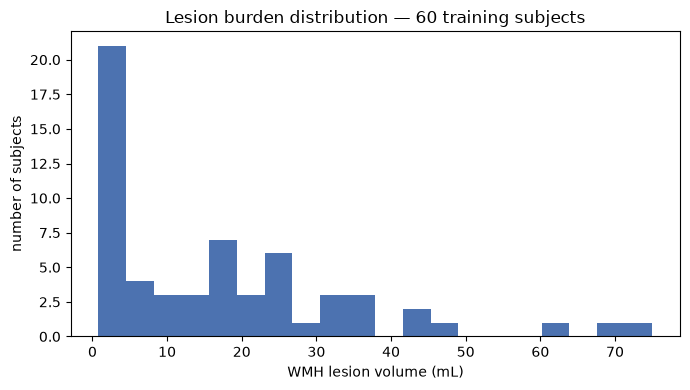

mean 17.61 mL | median 15.06 mL | min 0.79 mL | max 74.99 mL


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lesion_df["lesion_volume_ml"], bins=20, color="#4c72b0")
ax.set_xlabel("WMH lesion volume (mL)")
ax.set_ylabel("number of subjects")
ax.set_title("Lesion burden distribution — 60 training subjects")
plt.tight_layout()
plt.show()

print(f"mean {lesion_df.lesion_volume_ml.mean():.2f} mL | median {lesion_df.lesion_volume_ml.median():.2f} mL | "
      f"min {lesion_df.lesion_volume_ml.min():.2f} mL | max {lesion_df.lesion_volume_ml.max():.2f} mL")

A long right-hand tail (a few subjects carry a very heavy lesion load) and nobody in this cohort has zero lesions. That skew is exactly why any later severity classification (mild/moderate/severe) should work on the log-transformed volume rather than the raw mL value.

### c) Voxel level imbalance

This is the imbalance that actually matters for a segmentation model. What fraction of image voxels are WMH vs normal tissue?

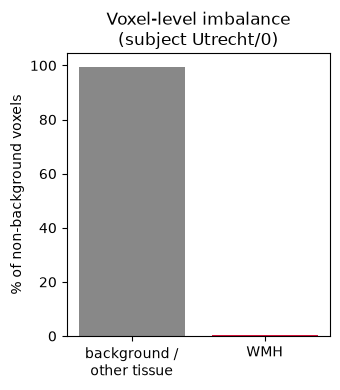

non-zero FLAIR voxels (rough head proxy): 1,738,050
WMH voxels: 8,778
WMH share: 0.505 %


In [8]:
hero = TRAIN_ROOT / "Utrecht" / "0"
flair_data = np.asarray(load_canonical(hero / "pre" / "FLAIR.nii.gz").dataobj)
wmh_data = np.asarray(load_canonical(hero / "wmh.nii.gz").dataobj)

nonzero_voxels = int(np.sum(flair_data > 0))
wmh_voxels = int(np.sum(wmh_data == 1))
pct_wmh = 100 * wmh_voxels / nonzero_voxels

fig, ax = plt.subplots(figsize=(3.5, 4))
ax.bar(["background /\nother tissue", "WMH"], [100 - pct_wmh, pct_wmh], color=["#888888", "crimson"])
ax.set_ylabel("% of non-background voxels")
ax.set_title(f"Voxel-level imbalance\n(subject Utrecht/0)")
plt.tight_layout()
plt.show()

print(f"non-zero FLAIR voxels (rough head proxy): {nonzero_voxels:,}")
print(f"WMH voxels: {wmh_voxels:,}")
print(f"WMH share: {pct_wmh:.3f} %")

## 3. Understanding the file format

### What is NIfTI?

**NIfTI** (`.nii` / `.nii.gz`) is the standard file format for 3D (and 4D) brain imaging data in research pipelines.

One file = one whole 3D volume, not dozens of separate 2D slice files the way DICOM stores a scan.

A NIfTI file has two parts:
1. A small header (metadata)
2. The image array (voxel intensities).

The header carries an **affine matrix** which maps every voxel index `(i, j, k)` to a real-world position in millimetres.

This is what lets software know exactly where and how big a voxel is.

Below is the header actually read off one of our own files, not a textbook example:

In [9]:
demo_path = TRAIN_ROOT / "Utrecht" / "0" / "pre" / "FLAIR.nii.gz"
demo_img = nib.load(demo_path)

print("file:", demo_path.relative_to(DATA_ROOT))
print("array shape:", demo_img.shape)
print("voxel spacing (mm):", tuple(round(float(z), 3) for z in demo_img.header.get_zooms()))
print("data type:", demo_img.get_data_dtype())
print("orientation (axis codes):", nib.aff2axcodes(demo_img.affine))
print("\naffine matrix (voxel index -> world mm):")
print(demo_img.affine)

file: training/Utrecht/0/pre/FLAIR.nii.gz
array shape: (240, 240, 48)
voxel spacing (mm): (0.958, 0.958, 3.0)
data type: float32
orientation (axis codes): ('L', 'P', 'S')

affine matrix (voxel index -> world mm):
[[-9.55749035e-01 -4.81770411e-02  1.60402849e-01  1.18610664e+02]
 [ 2.20411010e-02 -8.68188620e-01 -1.26836812e+00  1.27181854e+02]
 [ 6.67887405e-02 -4.02902126e-01  2.71394706e+00  1.33168182e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


### Why NIfTI and not DICOM?

Scans come off the scanner as **DICOM** (one file per 2D slice).

For a research pipeline, DICOM is not ideal. A single brain scan can be 50–300+ separate files, slice ordering has to be reconstructed, etc. so it's a huge hassle.

NIfTI packages the whole 3D volume as **one array + one affine**, which is exactly what volumetric operations need.

The dataset organisers already performed the DICOM → NIfTI conversion during acquisition.

## 4. Reading and displaying the data in Python

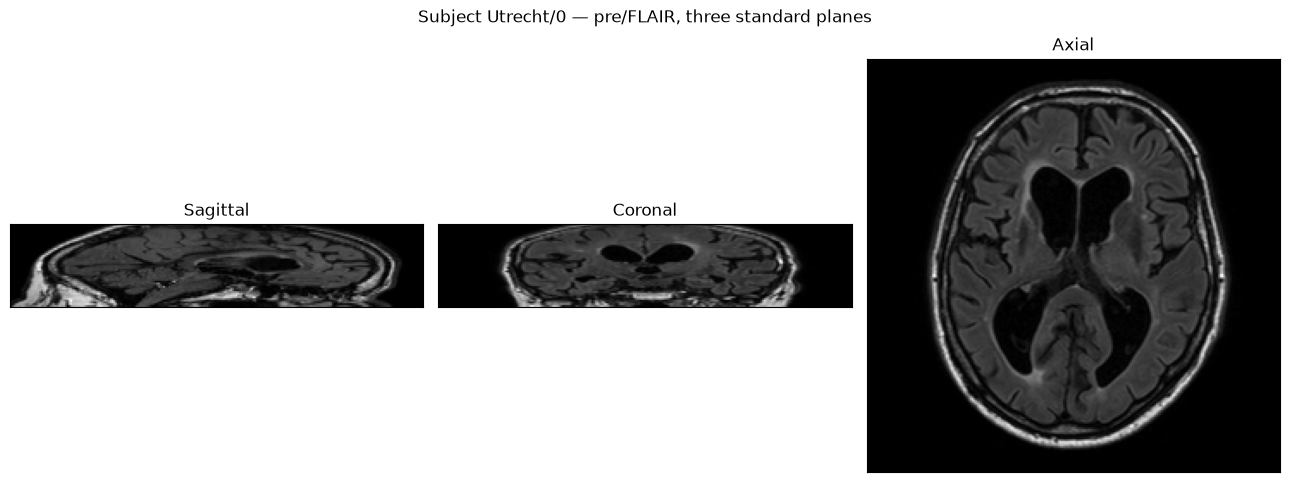

In [10]:
hero_dir = TRAIN_ROOT / "Utrecht" / "0"
flair_img = load_canonical(hero_dir / "pre" / "FLAIR.nii.gz")
flair_data = np.asarray(flair_img.dataobj)

sx, sy, sz = (s // 2 for s in flair_data.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].imshow(flair_data[sx, :, :].T, cmap="gray", origin="lower"); axes[0].set_title("Sagittal")
axes[1].imshow(flair_data[:, sy, :].T, cmap="gray", origin="lower"); axes[1].set_title("Coronal")
axes[2].imshow(flair_data[:, :, sz].T, cmap="gray", origin="lower"); axes[2].set_title("Axial")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Subject Utrecht/0 — pre/FLAIR, three standard planes")
plt.tight_layout()
plt.show()

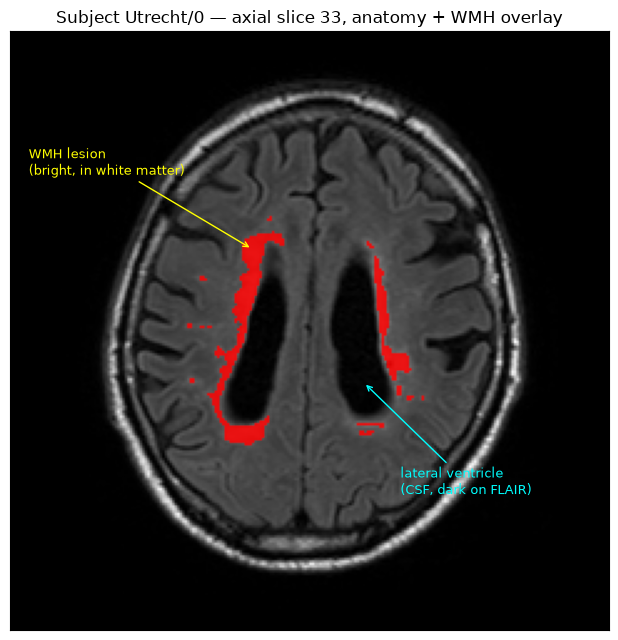

In [ ]:
wmh_data = np.asarray(load_canonical(hero_dir / "wmh.nii.gz").dataobj)

lesion_voxels_per_slice = np.sum(wmh_data == 1, axis=(0, 1))
best_z = int(np.argmax(lesion_voxels_per_slice))
slc = flair_data[:, :, best_z]
slc_wmh = wmh_data[:, :, best_z] == 1
brain = slc > 0

def deepest_point(mask):
    """Point that's maximally far from the mask's own edge, via a distance transform --
    lands solidly inside a blob rather than near its boundary (where a plain centroid
    can end up if the blob is curved or two separate blobs get averaged together)."""
    dist = ndimage.distance_transform_edt(mask)
    idx = np.unravel_index(np.argmax(dist), mask.shape)
    return int(idx[0]), int(idx[1])

def find_ventricle_points(slc, brain):
    """Finds the two lateral ventricles on one axial slice: threshold the darkest ~20%
    of intensities within the central half of the brain (where the ventricles sit), keep
    the two largest connected dark blobs, and return each one's deepest interior point.
    A toy version of the 'FLAIR dark-CSF' heuristic in our project notes (CLAUDE.md 11.1) --
    a real per-subject ventricle segmentation is a later, separate task."""
    ys_b, xs_b = np.where(brain)
    x0, x1, y0, y1 = xs_b.min(), xs_b.max(), ys_b.min(), ys_b.max()
    w, h = x1 - x0, y1 - y0
    cx0, cx1 = int(x0 + 0.25 * w), int(x0 + 0.75 * w)
    cy0, cy1 = int(y0 + 0.25 * h), int(y0 + 0.75 * h)
    central = np.zeros_like(brain)
    central[cx0:cx1, cy0:cy1] = True

    thresh = np.percentile(slc[brain & central], 20)
    dark = brain & central & (slc < thresh)
    labeled, n = ndimage.label(dark, structure=np.ones((3, 3)))
    sizes = ndimage.sum(dark, labeled, range(1, n + 1))
    top2 = np.argsort(sizes)[::-1][:2] + 1
    return [deepest_point(labeled == lbl) for lbl in top2]

def find_lesion_points(wmh_slice, n=2, min_separation=30):
    """Up to n well-separated WMH lesion points: largest connected components first
    (8-connectivity, matching the official challenge scorer), skipping any candidate
    that lands too close to one already picked -- so two picks are two different lesions,
    not two fragments of the same one."""
    labeled, n_comp = ndimage.label(wmh_slice, structure=np.ones((3, 3)))
    sizes = ndimage.sum(wmh_slice, labeled, range(1, n_comp + 1))
    order = np.argsort(sizes)[::-1]
    points = []
    for i in order:
        px, py = deepest_point(labeled == i + 1)
        if all((px - qx) ** 2 + (py - qy) ** 2 > min_separation ** 2 for qx, qy in points):
            points.append((px, py))
        if len(points) == n:
            break
    return points

vent_x, vent_y = find_ventricle_points(slc, brain)[0]
lesion_x, lesion_y = find_lesion_points(slc_wmh, n=1)[0]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(flair_data[:, :, best_z].T, cmap="gray", origin="lower")
wmh_masked = np.ma.masked_where(wmh_data[:, :, best_z].T != 1, wmh_data[:, :, best_z].T)
ax.imshow(wmh_masked, cmap="autumn", alpha=0.85, origin="lower")

ax.annotate("lateral ventricle\n(CSF, dark on FLAIR)", xy=(vent_x, vent_y),
            xytext=(vent_x + 15, vent_y - 45), color="cyan", fontsize=9, ha="left",
            arrowprops=dict(arrowstyle="->", color="cyan", shrinkA=0, shrinkB=3))
ax.annotate("WMH lesion\n(bright, in white matter)", xy=(lesion_x, lesion_y),
            xytext=(lesion_x - 90, lesion_y + 30), color="yellow", fontsize=9, ha="left",
            arrowprops=dict(arrowstyle="->", color="yellow", shrinkA=0, shrinkB=3))

ax.set_title(f"Subject Utrecht/0 — axial slice {best_z}, anatomy + WMH overlay")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

The anatomical structures relevant to this project are labelled directly on the image here.
- The ventricles
- WMH lesion

Ventricles are dark since FLAIR is specifically designed to suppress CSF signal.

Lesions are bright, sitting in the white matter. They are red in this image because of the WMH overlay.

## 5. Manually marking the segments of interest

Hand-markings done on a few sample images for the structures we'll later identify with code.

**Panel A:** Circling the ventricle and the two clearest WMH lesions on this slice by eye.

**Panel B:** The expert-drawn reference mask that ships with this dataset (`wmh.nii.gz`), shown purely as a reference for comparison.

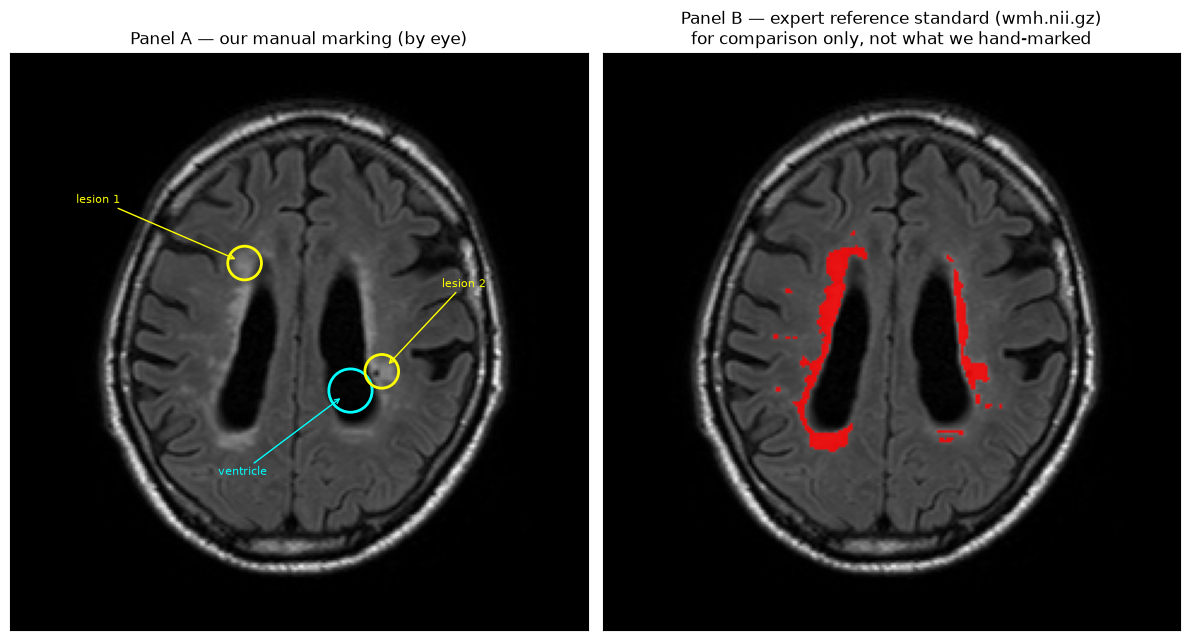

In [12]:
lesion_points = find_lesion_points(slc_wmh, n=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6.5))

axes[0].imshow(flair_data[:, :, best_z].T, cmap="gray", origin="lower")
axes[0].add_patch(plt.Circle((vent_x, vent_y), 9, fill=False, color="cyan", linewidth=2))
axes[0].annotate("ventricle", xy=(vent_x, vent_y), xytext=(vent_x - 55, vent_y - 35),
                  color="cyan", fontsize=8, ha="left",
                  arrowprops=dict(arrowstyle="->", color="cyan", shrinkA=0, shrinkB=9))

lesion_label_offsets = [(-70, 25), (25, 35)]
for (lx, ly), offset, i in zip(lesion_points, lesion_label_offsets, range(1, len(lesion_points) + 1)):
    ox, oy = offset
    axes[0].add_patch(plt.Circle((lx, ly), 7, fill=False, color="yellow", linewidth=2))
    axes[0].annotate(f"lesion {i}", xy=(lx, ly), xytext=(lx + ox, ly + oy),
                      color="yellow", fontsize=8, ha="left",
                      arrowprops=dict(arrowstyle="->", color="yellow", shrinkA=0, shrinkB=7))
axes[0].set_title("Panel A — our manual marking (by eye)")
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].imshow(flair_data[:, :, best_z].T, cmap="gray", origin="lower")
axes[1].imshow(wmh_masked, cmap="autumn", alpha=0.85, origin="lower")
axes[1].set_title("Panel B — expert reference standard (wmh.nii.gz)\nfor comparison only, not what we hand-marked")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()

## 6. Project objectives

This project designs a pipeline to detect and segment WMHs, clinically tied to cerebrovascular disease,
ageing, and dementia risk.

In plain terms, here's what we're building:  
1. Pre-process each scan  
2. Segment WMH lesions on FLAIR  
3. Label each lesion anatomically (periventricular vs. deep white matter)  
4. Extract quantitative features per subject  
5. Classify overall WMH lesion as mild/moderate/severe, and benchmark the whole pipeline against
the ofﬁcial WMH Segmentation Challenge leaderboard so our results mean something outside our
own dataset.  




